In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:qwen/qwen3-32b")

In [3]:
llm 

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001CB753E6CF0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CB76517260>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [4]:
# from enum import Enum

# class Stage(str, Enum):
#     ACCOUNT_ID = "awaiting_account_id"
#     VERIFICATION = "awaiting_verification"
#     PAYMENT_AMOUNT = "awaiting_payment_amount"
#     CARD_DETAILS = "awaiting_card_details"
#     PROCESS_PAYMENT = "processing_payment"
#     COMPLETED = "completed"

In [ ]:
from typing import Optional
from pydantic import BaseModel, Field


class CollectedInfo(BaseModel):
    account_id: Optional[str] = Field(default=None)
    full_name: Optional[str] = Field(default=None)

    dob: Optional[str] = Field(default=None)
    aadhaar_last4: Optional[str] = Field(default=None)
    pincode: Optional[str] = Field(default=None)

    amount: Optional[float] = Field(default=None)

    cardholder_name: Optional[str] = Field(default=None)
    card_number: Optional[str] = Field(default=None)
    cvv: Optional[str] = Field(default=None)

    expiry_month: Optional[int] = Field(default=None)
    expiry_year: Optional[int] = Field(default=None)

class ConversationState(BaseModel):
    user_input: str = ""

    account_id: Optional[str] = None
    account_data: Optional[dict] = None

    full_name: Optional[str] = None
    dob: Optional[str] = None
    aadhaar_last4: Optional[str] = None
    pincode: Optional[str] = None

    verified: bool = False
    verification_attempts: int = 0

    balance: Optional[float] = None

    amount: Optional[float] = None

    cardholder_name: Optional[str] = None
    card_number: Optional[str] = None
    cvv: Optional[str] = None
    expiry_month: Optional[int] = None
    expiry_year: Optional[int] = None

    transaction_id: Optional[str] = None

    stage: str = "awaiting_account_id"

    response: str = ""

In [6]:
model = llm.with_structured_output(CollectedInfo)

In [7]:
def extract_information(user_input: str) -> CollectedInfo:
    return model.invoke(
        f"""
        Extract any payment collection information
        from the user message.

        User Message:
        {user_input}
        """
    )

In [8]:
extract_information(
    "yeah my account number is ACC1001 and my date of birth is 18 April 2003"
)

CollectedInfo(account_id='ACC1001', full_name=None, dob='18 April 2003', aadhaar_last4=None, pincode=None, amount=None, cardholder_name=None, card_number=None, cvv=None, expiry_month=None, expiry_year=None)

In [9]:
extract_information(
    "i was born on 18th april 2003"
)

CollectedInfo(account_id=None, full_name=None, dob='2003-04-18', aadhaar_last4=None, pincode=None, amount=None, cardholder_name=None, card_number=None, cvv=None, expiry_month=None, expiry_year=None)

In [10]:
def verify_user(state):

    account = state.account_data

    result = {
        "verified": False,
        "name_match": False,
        "secondary_match": False
    }

    if not account:
        return result

    result["name_match"] = (
        state.full_name == account["full_name"]
    )

    dob_match = (
        state.dob == account["dob"]
        if state.dob else False
    )

    aadhaar_match = (
        state.aadhaar_last4 ==
        account["aadhaar_last4"]
        if state.aadhaar_last4 else False
    )

    pincode_match = (
        state.pincode ==
        account["pincode"]
        if state.pincode else False
    )

    result["secondary_match"] = (
        dob_match
        or
        aadhaar_match
        or
        pincode_match
    )

    result["verified"] = (
        result["name_match"]
        and
        result["secondary_match"]
    )

    return result

In [11]:
def update_state(
    state: ConversationState,
    extracted: CollectedInfo
):
    data = extracted.model_dump(
        exclude_none=True
    )

    for key, value in data.items():
        setattr(state, key, value)

    return state

In [12]:
import requests

BASE_URL = "https://se-payment-verification-api.service.external.usea2.aws.prodigaltech.com"

def lookup_account(account_id: str) -> dict:
    """
    Lookup account details from API.
    """

    payload = {
        "account_id": account_id
    }

    response = requests.post(
        f"{BASE_URL}/api/lookup-account",
        json=payload,
        timeout=10
    )

    if response.status_code == 200:
        return response.json()

    if response.status_code == 404:
        return {
            "error": "account_not_found"
        }

    return {
        "error": "api_failure"
    }

In [13]:
print(lookup_account("ACC1234"))

{'error': 'account_not_found'}


In [14]:
print(lookup_account("ACC1001"))

{'account_id': 'ACC1001', 'full_name': 'Nithin Jain', 'dob': '1990-05-14', 'aadhaar_last4': '4321', 'pincode': '400001', 'balance': 1250.75}


In [15]:
def save_account_data(
    state,
    account_data
):
    state.account_data = account_data
    state.balance = account_data.get("balance")

    return state

In [16]:
def lookup_account_node(
    state
):
    
    result = lookup_account(
        state.account_id
    )

    if "error" in result:

        if result["error"] == "account_not_found":

            state.response = (
                "I couldn't find an account "
                "with that account ID. "
                "Please check and try again."
            )

            return state

        state.response = (
            "I'm having trouble accessing "
            "account information right now."
        )

        return state

    state.account_data = result

    state.balance = result["balance"]

    state.response = (
        "Thank you. Please provide your "
        "full name for verification."
    )

    return state

In [17]:
def route_after_extraction(
    state
):
    
    if not state.account_id:
        return "ask_account"

    if state.account_data is None:
        return "lookup_account"

    return "verification"

### Testing

In [18]:
message = """
my account id is ACC1001 and my name is Nithin Jain
"""

extracted = extract_information(message)

print(extracted)

account_id='ACC1001' full_name='Nithin Jain' dob=None aadhaar_last4=None pincode=None amount=None cardholder_name=None card_number=None cvv=None expiry_month=None expiry_year=None


In [19]:
state = ConversationState()

extracted = CollectedInfo(
    account_id="ACC1001",
    full_name="Nithin Jain"
)

state = update_state(state, extracted)

print(state)

user_input='' account_id='ACC1001' account_data=None full_name='Nithin Jain' dob=None aadhaar_last4=None pincode=None verified=False verification_attempts=0 balance=None amount=None cardholder_name=None card_number=None cvv=None expiry_month=None expiry_year=None transaction_id=None stage='awaiting_account_id' response=''


In [20]:
result = lookup_account("ACC1001")

print(result)

{'account_id': 'ACC1001', 'full_name': 'Nithin Jain', 'dob': '1990-05-14', 'aadhaar_last4': '4321', 'pincode': '400001', 'balance': 1250.75}


In [21]:
result = lookup_account("ACC9999")

print(result)

{'error': 'account_not_found'}


In [24]:
state = ConversationState()

state.account_data = {
    "full_name": "Nithin Jain",
    "dob": "1990-05-14",
    "aadhaar_last4": "4321",
    "pincode": "400001"
}

state.full_name = "Nithin Jain"
state.dob = "1990-05-14"

print(
    verify_user(state)
)

{'verified': True, 'name_match': True, 'secondary_match': True}


In [23]:
state = ConversationState()

while True:

    user_input = input("User: ")
    if user_input == "q":
        break
    extracted = extract_information(user_input)

    state = update_state(
        state,
        extracted
    )

    print(state)

user_input='' account_id=None account_data=None full_name=None dob=None aadhaar_last4=None pincode=None verified=False verification_attempts=0 balance=None amount=None cardholder_name=None card_number=None cvv=None expiry_month=None expiry_year=None transaction_id=None stage='awaiting_account_id' response=''
user_input='' account_id=None account_data=None full_name=None dob=None aadhaar_last4=None pincode=None verified=False verification_attempts=0 balance=None amount=None cardholder_name=None card_number=None cvv=None expiry_month=None expiry_year=None transaction_id=None stage='awaiting_account_id' response=''
user_input='' account_id=None account_data=None full_name=None dob=None aadhaar_last4=None pincode=None verified=False verification_attempts=0 balance=None amount=None cardholder_name=None card_number=None cvv=None expiry_month=None expiry_year=None transaction_id=None stage='awaiting_account_id' response=''
user_input='' account_id=None account_data=None full_name='Harshitha r

### LangGraph

In [40]:
from langgraph.graph import END, StateGraph, START

In [41]:
from typing import Optional
from pydantic import BaseModel


class ConversationState(BaseModel):
    user_input: str = ""

    account_id: Optional[str] = None
    account_data: Optional[dict] = None

    full_name: Optional[str] = None
    dob: Optional[str] = None
    aadhaar_last4: Optional[str] = None
    pincode: Optional[str] = None

    verified: bool = False

    balance: Optional[float] = None

    response: str = ""

In [46]:
def extract_node(state: ConversationState):

    extracted = extract_information(
        state.user_input
    )

    data = extracted.model_dump(
        exclude_none=True
    )

    for key, value in data.items():
        setattr(state, key, value)

    return state

In [47]:
def lookup_node(state: ConversationState):

    if not state.account_id:
        state.response = (
            "Please provide your account ID."
        )
        return state

    if state.account_data:
        return state

    result = lookup_account(
        state.account_id
    )

    if "error" in result:

        state.response = (
            "Account not found."
        )

        return state

    state.account_data = result
    state.balance = result["balance"]

    state.response = (
        "Please provide your full name and either "
        "your DOB, Aadhaar last 4 digits, or pincode."
    )

    return state

In [48]:
def verification_node(state):

    if not state.account_data:
        return state

    if not state.full_name:

        state.response = (
            "Please provide your full name."
        )

        return state

    secondary_exists = any([
        state.dob,
        state.aadhaar_last4,
        state.pincode
    ])

    if not secondary_exists:

        state.response = (
            "Please provide your DOB, "
            "Aadhaar last 4, or pincode."
        )

        return state

    result = verify_user(state)

    if result["verified"]:

        state.verified = True

        state.response = (
            f"Identity verified. "
            f"Outstanding balance is ₹{state.balance:.2f}"
        )

    else:

        state.response = (
            "Verification failed."
        )

    return state

In [60]:
from langgraph.graph import END

def router(state):

    if state.account_id and not state.account_data:
        return "lookup"

    if (
        state.account_data
        and state.full_name
        and (
            state.dob
            or state.aadhaar_last4
            or state.pincode
        )
        and not state.verified
    ):
        return "verification"

    return END

In [ ]:
from langgraph.graph import (
    StateGraph,
    START,
    END
)

builder = StateGraph(
    ConversationState
)

builder.add_node(
    "extract",
    extract_node
)

builder.add_node(
    "lookup",
    lookup_node
)

builder.add_node(
    "verification",
    verification_node
)

builder.add_edge(
    START,
    "extract"
)

builder.add_conditional_edges(
    "extract",
    router
)

builder.add_conditional_edges(
    "lookup",
    router
)

builder.add_conditional_edges(
    "verification",
    router
)

graph = builder.compile()

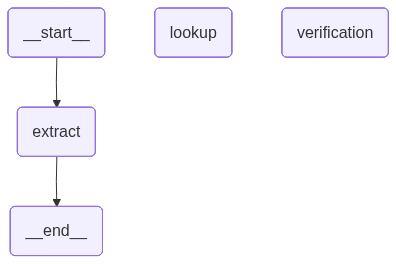

In [62]:
graph

In [64]:
# from graph import graph
# from state import ConversationState


def chat():

    state = ConversationState()

    print("Payment Agent Started")
    print("-" * 50)

    while True:

        user_input = input("\nUser: ")

        if user_input.lower() in ["quit", "exit"]:
            break

        state.user_input = user_input

        result = graph.invoke(
            state.model_dump()
        )

        state = ConversationState(
            **result
        )

        print(f"\nAgent: {state.response}")


if __name__ == "__main__":
    chat()

Payment Agent Started
--------------------------------------------------
